# TTN interval 各 band 疾病分布

使用 `HGMD_TTN_processed (1).xlsx` 的資料，依 TTN (chr2, 負股) 的**結構分區 (band)** 將變異分組，並繪製每個 band 上各疾病類型 (`phenotype`: cardiac / skeletal / both / unsure) 的分布情形。

TTN 基因座標範圍：**178,525,989 – 178,807,423**。各 band 定義（基因組座標，由 N 端 Z-disk 到 C 端 M-band）：

| band | 基因組座標 (chr2) | 長度 (bp) |
|---|---|---|
| Z-disk | 178,775,356 – 178,807,423 | 32,067 |
| I-band | 178,618,584 – 178,775,356 | 156,772 |
| A-band | 178,535,982 – 178,618,584 | 82,602 |
| M-band | 178,525,989 – 178,535,982 | 9,993 |

（TTN 位於負股，故 Z-disk 對應較大的基因組座標。）

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 設定支援中文的字型 (Noto Sans CJK)
mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Droid Sans Fallback', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False

FILE = 'HGMD_TTN_processed (1).xlsx'
df = pd.read_excel(FILE)
print('shape:', df.shape)
df[['#CHROM', 'POS', 'GENE', 'PHEN', 'phenotype']].head()

shape: (1094, 24)


,#CHROM,POS,GENE,PHEN,phenotype
0,2,178527031,TTN,Skeletal myopathy,skeletal
1,2,178527098,TTN,Tibial muscular dystrophy,skeletal
2,2,178527121,TTN,Tibial muscular dystrophy,skeletal
3,2,178527148,TTN,Tibial muscular dystrophy,skeletal
4,2,178527148,TTN,Cardiomyopathy; dilated,cardiac


## 1. 定義 TTN 結構 band 並標記每個變異

依基因組座標 `POS` 把每個變異對應到所屬的結構 band。band 順序由 N 端 (Z-disk) 至 C 端 (M-band)。

In [12]:
TTN_START, TTN_END = 178525989, 178807423

# (band 名稱, 起點, 終點)  —— 起點 < 終點
band_defs = [
    ('M-band', 178525989, 178535982),
    ('A-band', 178535982, 178618584),
    ('I-band', 178618584, 178775356),
    ('Z-disk', 178775356, 178807423),
]

# 繪圖呈現順序：N 端 -> C 端
band_order = ['Z-disk', 'I-band', 'A-band', 'M-band']

edges = [b[1] for b in band_defs] + [band_defs[-1][2]]
labels_asc = [b[0] for b in band_defs]
df['band'] = pd.cut(df['POS'], bins=edges, labels=labels_asc, include_lowest=True)

# 檢查是否有變異落在定義範圍外
n_out = df['band'].isna().sum()
print(f'落在 band 範圍外的變異數: {n_out}')
print(f'POS 範圍: {df["POS"].min():,} – {df["POS"].max():,}')
df[['POS', 'band', 'phenotype']].head()

落在 band 範圍外的變異數: 0
POS 範圍: 178,527,031 – 178,802,316


,POS,band,phenotype
0,178527031,M-band,skeletal
1,178527098,M-band,skeletal
2,178527121,M-band,skeletal
3,178527148,M-band,skeletal
4,178527148,M-band,cardiac


## 2. 統計各 band 的疾病分布

統計每個 band 內各 phenotype 的變異數量。

In [13]:
pheno_order = ['cardiac', 'skeletal', 'both', 'others']
colors = {'cardiac': '#d62728', 'skeletal': '#1f77b4', 'both': '#9467bd', 'others': '#7f7f7f'}

counts = (df.groupby(['band', 'phenotype'], observed=False)
            .size()
            .unstack('phenotype')
            .reindex(index=band_order, columns=pheno_order)
            .fillna(0)
            .astype(int))
counts['total'] = counts.sum(axis=1)
counts

phenotype,cardiac,skeletal,both,others,total
band,,,,,
Z-disk,38,18,0,0,56
I-band,193,127,11,0,331
A-band,468,137,7,0,612
M-band,44,40,2,0,86


## 3. 各 band 疾病分布（堆疊長條圖：數量）

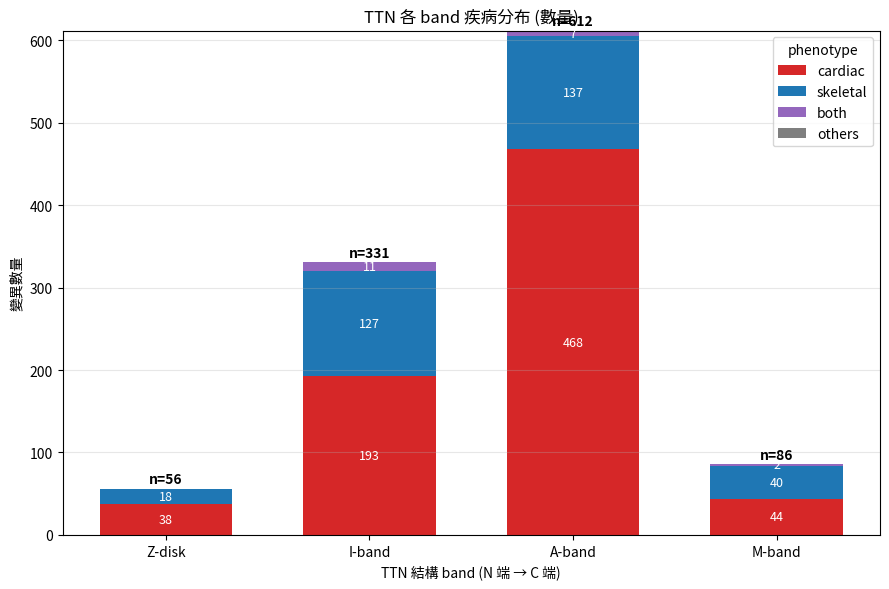

In [14]:
x = np.arange(len(band_order))
fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(len(band_order))
for ph in pheno_order:
    vals = counts.loc[band_order, ph].values
    bars = ax.bar(x, vals, bottom=bottom, label=ph, color=colors[ph], width=0.65)
    # 在每個 segment 標數量
    for xi, v, b in zip(x, vals, bottom):
        if v > 0:
            ax.text(xi, b + v / 2, int(v), ha='center', va='center', fontsize=9, color='white')
    bottom += vals

# 總數標在柱頂
for xi, t in zip(x, counts.loc[band_order, 'total'].values):
    ax.text(xi, t + 3, f'n={t}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(band_order)
ax.set_xlabel('TTN 結構 band (N 端 → C 端)')
ax.set_ylabel('變異數量')
ax.set_title('TTN 各 band 疾病分布 (數量)')
ax.legend(title='phenotype')
ax.grid(axis='y', alpha=0.3)
ax.margins(y=0.1)
plt.tight_layout()
plt.show()

## 4. 各 band 疾病組成比例（100% 堆疊圖）

以比例呈現每個 band 內疾病類型的相對占比，柱頂標示該 band 的變異總數。

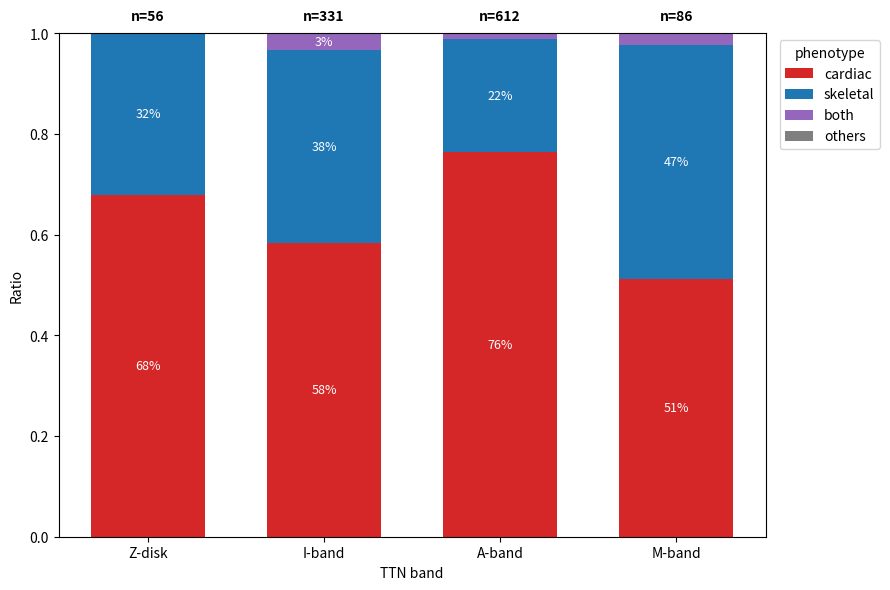

In [15]:
prop = counts.loc[band_order, pheno_order].div(counts.loc[band_order, 'total'], axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(len(band_order))
for ph in pheno_order:
    vals = prop[ph].values
    ax.bar(x, vals, bottom=bottom, label=ph, color=colors[ph], width=0.65)
    for xi, v, b in zip(x, vals, bottom):
        if v > 0.03:
            ax.text(xi, b + v / 2, f'{v*100:.0f}%', ha='center', va='center', fontsize=9, color='white')
    bottom += vals

for xi, t in zip(x, counts.loc[band_order, 'total'].values):
    ax.text(xi, 1.02, f'n={t}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(band_order)
ax.set_xlabel('TTN band')
ax.set_ylabel('Ratio')
ax.set_ylim(0, 1)
ax.legend(title='phenotype', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. 進階：用密度看疾病沿 TTN 的分布

band 長度差異很大（I-band 約 157 kb，M-band 僅約 10 kb），柱狀比較數量會受長度影響。這裡計算每個 band 的**變異密度**（每 10 kb 的變異數），並標示 band 邊界，更能反映沿 TTN 的疾病熱點。

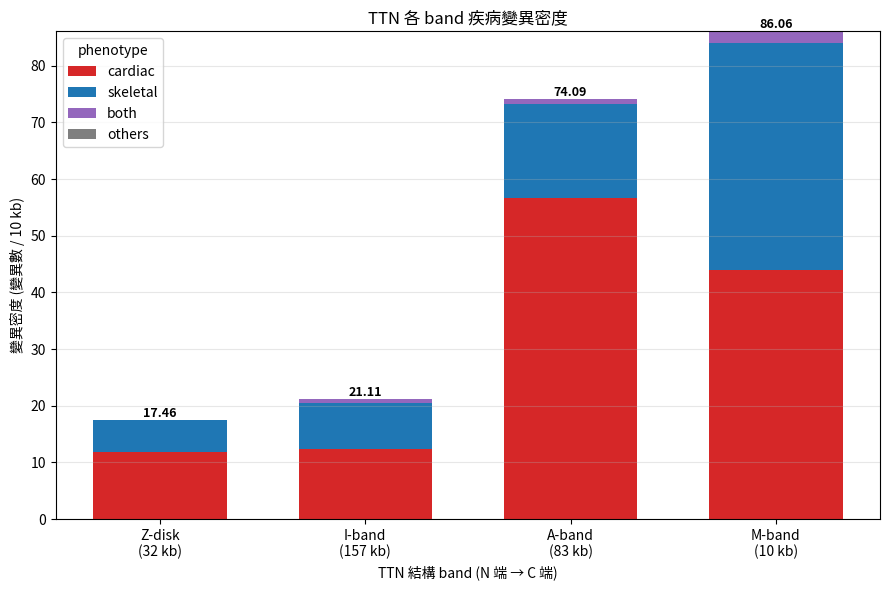

In [16]:
band_len = {name: end - start for name, start, end in band_defs}
dens = pd.DataFrame(index=band_order)
for ph in pheno_order:
    dens[ph] = [counts.loc[b, ph] / band_len[b] * 1e4 for b in band_order]
dens['total'] = [counts.loc[b, 'total'] / band_len[b] * 1e4 for b in band_order]

fig, ax = plt.subplots(figsize=(9, 6))
bottom = np.zeros(len(band_order))
for ph in pheno_order:
    vals = dens[ph].values
    ax.bar(x, vals, bottom=bottom, label=ph, color=colors[ph], width=0.65)
    bottom += vals

for xi, b in zip(x, band_order):
    ax.text(xi, dens.loc[b, 'total'] + 0.05, f'{dens.loc[b, "total"]:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{b}\n({band_len[b]/1000:.0f} kb)' for b in band_order])
ax.set_xlabel('TTN 結構 band (N 端 → C 端)')
ax.set_ylabel('變異密度 (變異數 / 10 kb)')
ax.set_title('TTN 各 band 疾病變異密度')
ax.legend(title='phenotype')
ax.grid(axis='y', alpha=0.3)
ax.margins(y=0.1)
plt.tight_layout()
plt.show()